# Import libraries

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error

import joblib
import warnings 
warnings.filterwarnings("ignore")

# Collects the data

In [2]:
PGINVIT = pd.read_csv("Quote-Equity-PGINVIT-BL,IV-22-03-2025-22-03-2026.csv")
PGINVIT

,DATE,SERIES,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,52W L,VOLUME,VALUE,NO. OF TRADES
0,20-Mar-2026,IV,90.69,90.98,90.11,90.01,90.89,90.81,90.63,98.19,74.96,1455925,"13,19,54,357.83",5975
1,19-Mar-2026,IV,90.25,91.30,89.90,90.20,90.00,90.01,90.22,98.19,74.96,2176809,"19,64,00,490.93",8277
2,18-Mar-2026,IV,90.36,91.00,90.06,90.35,90.35,90.20,90.50,98.19,74.96,1443112,"13,06,06,257.67",6450
3,17-Mar-2026,IV,90.11,90.58,89.95,90.11,90.41,90.35,90.11,98.19,74.96,1309905,"11,80,40,066.37",6041
4,16-Mar-2026,IV,90.90,90.97,90.01,90.51,90.10,90.11,90.33,98.19,74.96,1843867,"16,65,52,482.54",9449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,28-Mar-2025,IV,75.99,76.25,75.70,75.99,76.00,75.99,76.04,100.00,74.96,4289545,"32,61,71,489.41",9617
243,27-Mar-2025,IV,76.00,76.06,75.80,75.98,76.00,75.99,76.00,100.00,74.96,2727019,"20,72,48,809.56",6853
244,26-Mar-2025,IV,75.76,76.10,75.60,75.99,75.94,75.98,75.92,100.00,74.96,3723960,"28,27,28,264.35",7079
245,25-Mar-2025,IV,76.10,76.30,75.85,76.37,76.02,75.99,76.03,100.00,74.96,4124457,"31,35,63,307.81",8972


In [3]:
PGINVIT.tail()

,DATE,SERIES,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,52W L,VOLUME,VALUE,NO. OF TRADES
242,28-Mar-2025,IV,75.99,76.25,75.70,75.99,76.00,75.99,76.04,100.0,74.96,4289545,"32,61,71,489.41",9617
243,27-Mar-2025,IV,76.00,76.06,75.80,75.98,76.00,75.99,76.00,100.0,74.96,2727019,"20,72,48,809.56",6853
244,26-Mar-2025,IV,75.76,76.10,75.60,75.99,75.94,75.98,75.92,100.0,74.96,3723960,"28,27,28,264.35",7079
245,25-Mar-2025,IV,76.10,76.30,75.85,76.37,76.02,75.99,76.03,100.0,74.96,4124457,"31,35,63,307.81",8972
246,24-Mar-2025,IV,75.90,76.64,75.15,75.92,76.00,76.37,75.86,100.0,74.96,4221753,"32,02,77,830.33",13489


# Data understandig

In [4]:
PGINVIT.dtypes

DATE               object
SERIES             object
OPEN              float64
HIGH              float64
LOW               float64
PREV. CLOSE       float64
LTP               float64
CLOSE             float64
VWAP              float64
52W H             float64
52W L             float64
VOLUME              int64
VALUE              object
NO. OF  TRADES      int64
dtype: object

In [5]:
PGINVIT['DATE'] = pd.to_datetime(PGINVIT['DATE'],errors='coerce')
PGINVIT['VALUE']= PGINVIT['VALUE'].str.replace(',','').astype(float)

In [6]:
PGINVIT.isna().sum()

DATE              0
SERIES            0
OPEN              0
HIGH              0
LOW               0
PREV. CLOSE       0
LTP               0
CLOSE             0
VWAP              0
52W H             0
52W L             0
VOLUME            0
VALUE             0
NO. OF  TRADES    0
dtype: int64

In [7]:
PGINVIT.count()

DATE              247
SERIES            247
OPEN              247
HIGH              247
LOW               247
PREV. CLOSE       247
LTP               247
CLOSE             247
VWAP              247
52W H             247
52W L             247
VOLUME            247
VALUE             247
NO. OF  TRADES    247
dtype: int64

In [8]:
PGINVIT['52W L'].nunique()

1

In [9]:
PGINVIT.drop(columns=['SERIES'],inplace=True)


In [10]:
PGINVIT.drop(columns=['52W L'],axis=1,inplace=True)

In [11]:
PGINVIT.drop_duplicates()

,DATE,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,VOLUME,VALUE,NO. OF TRADES
0,2026-03-20,90.69,90.98,90.11,90.01,90.89,90.81,90.63,98.19,1455925,1.319544e+08,5975
1,2026-03-19,90.25,91.30,89.90,90.20,90.00,90.01,90.22,98.19,2176809,1.964005e+08,8277
2,2026-03-18,90.36,91.00,90.06,90.35,90.35,90.20,90.50,98.19,1443112,1.306063e+08,6450
3,2026-03-17,90.11,90.58,89.95,90.11,90.41,90.35,90.11,98.19,1309905,1.180401e+08,6041
4,2026-03-16,90.90,90.97,90.01,90.51,90.10,90.11,90.33,98.19,1843867,1.665525e+08,9449
...,...,...,...,...,...,...,...,...,...,...,...,...
242,2025-03-28,75.99,76.25,75.70,75.99,76.00,75.99,76.04,100.00,4289545,3.261715e+08,9617
243,2025-03-27,76.00,76.06,75.80,75.98,76.00,75.99,76.00,100.00,2727019,2.072488e+08,6853
244,2025-03-26,75.76,76.10,75.60,75.99,75.94,75.98,75.92,100.00,3723960,2.827283e+08,7079
245,2025-03-25,76.10,76.30,75.85,76.37,76.02,75.99,76.03,100.00,4124457,3.135633e+08,8972


In [12]:
PGINVIT.describe(include='number')

,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,VOLUME,VALUE,NO. OF TRADES
count,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,2.470000e+02,2.470000e+02,247.000000
mean,90.205263,90.722146,89.596235,90.076883,90.184372,90.137166,90.154089,97.928947,1.383037e+06,1.226898e+08,6568.194332
std,5.543709,5.412838,5.530530,5.506642,5.422257,5.432029,5.468082,1.433380,1.553260e+06,1.344504e+08,4305.158534
min,75.760000,76.060000,75.150000,75.920000,75.940000,75.980000,75.860000,94.500000,3.561800e+05,3.273770e+07,2410.000000
25%,87.750000,89.745000,87.075000,88.100000,88.650000,88.605000,88.320000,97.450000,7.668545e+05,6.991669e+07,4086.000000
50%,91.570000,91.980000,90.990000,91.370000,91.480000,91.370000,91.450000,98.190000,1.026919e+06,9.465953e+07,5402.000000
75%,94.315000,94.700000,93.830000,94.155000,94.195000,94.155000,94.115000,98.190000,1.648362e+06,1.460913e+08,7861.500000
max,97.970000,98.190000,97.260000,97.550000,97.450000,97.550000,97.620000,100.000000,2.213872e+07,1.944048e+09,38856.000000


# Check Assumptions

## Test  1 --> Linearity test

In [13]:
PGINVIT.columns

Index(['DATE', 'OPEN', 'HIGH', 'LOW', 'PREV. CLOSE', 'LTP', 'CLOSE', 'VWAP',
       '52W H', 'VOLUME', 'VALUE', 'NO. OF  TRADES'],
      dtype='object')

In [14]:
columns=['OPEN', 'HIGH', 'LOW', 'PREV. CLOSE', 'LTP',
       'VWAP', '52W H', 'VOLUME', 'VALUE', 'NO. OF  TRADES']

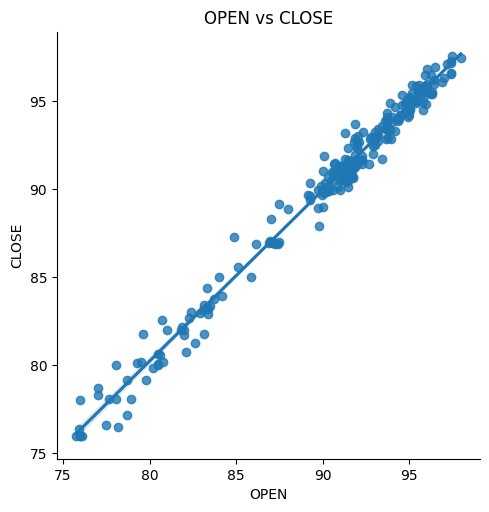

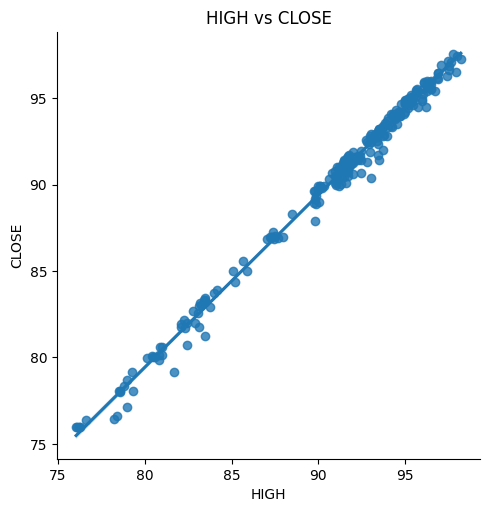

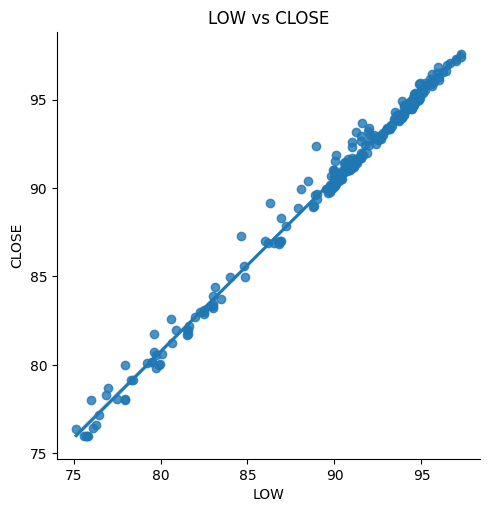

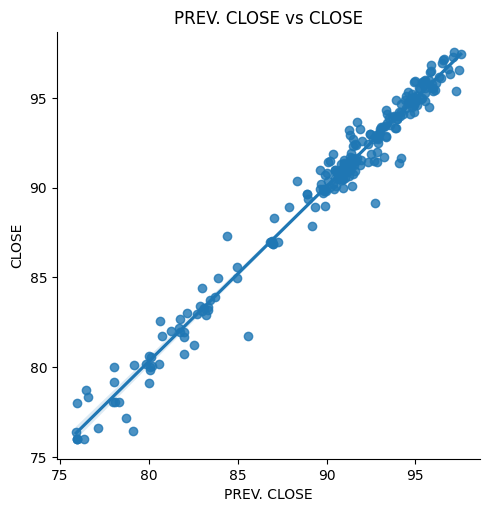

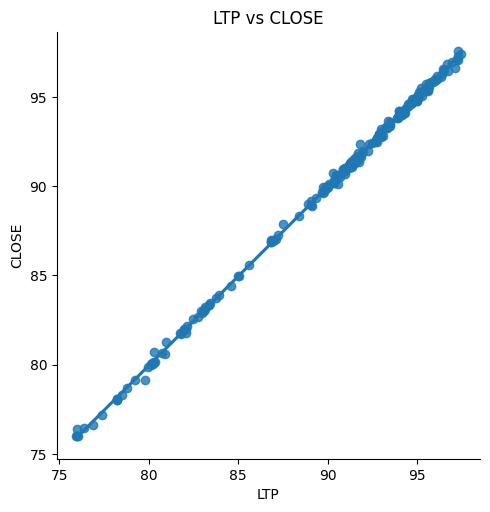

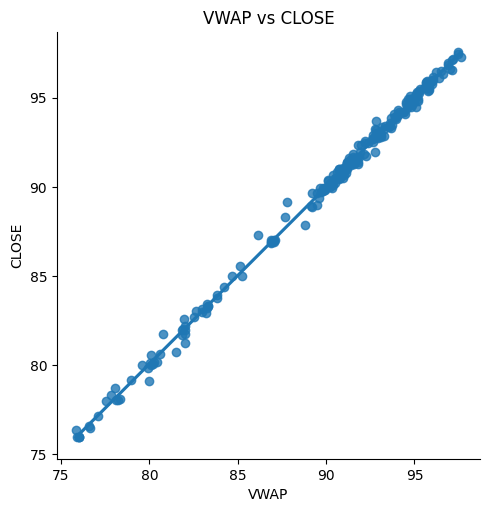

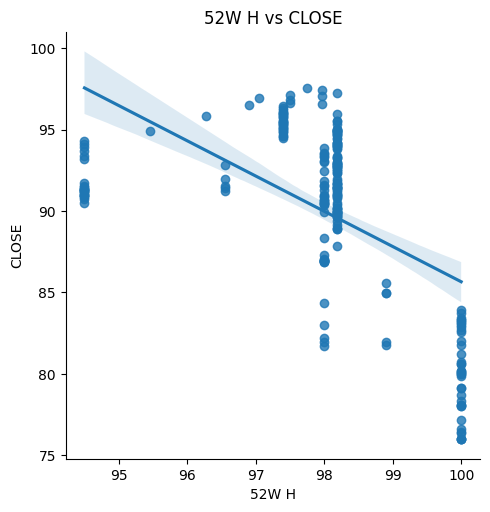

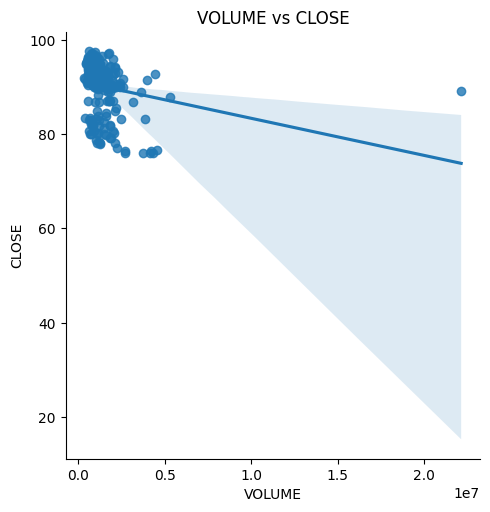

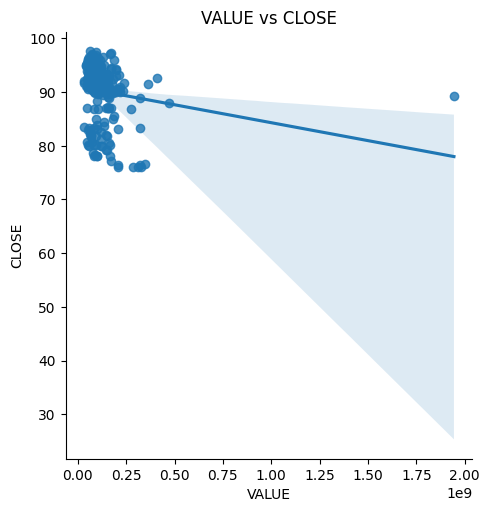

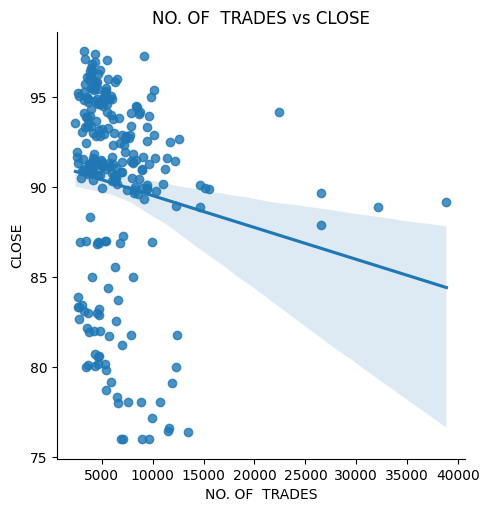

In [15]:
Target = 'CLOSE'

for col in columns:
    sns.lmplot(x=col,y=Target,data=PGINVIT)
    plt.title(f'{col} vs {Target}')
    plt.show()

## Test 2 --> Normality test

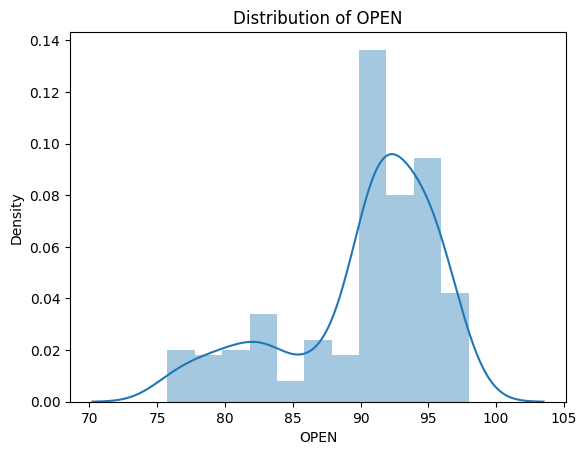

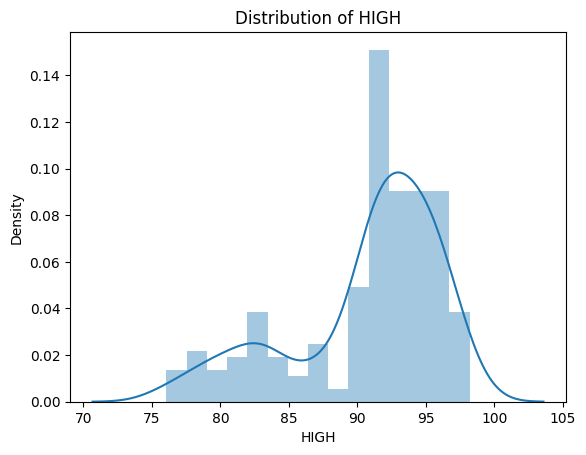

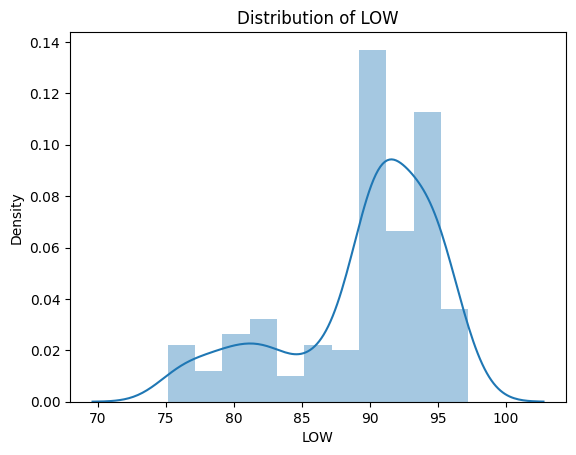

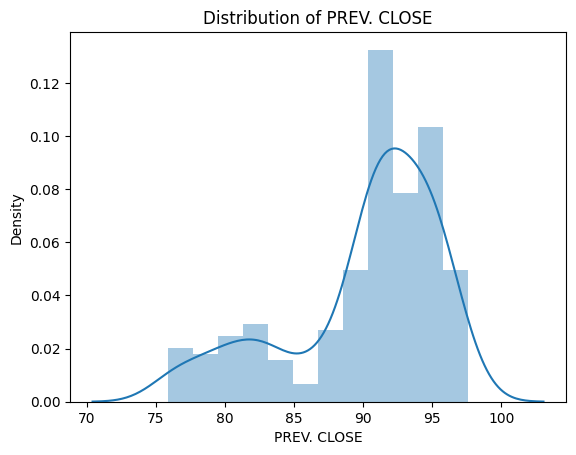

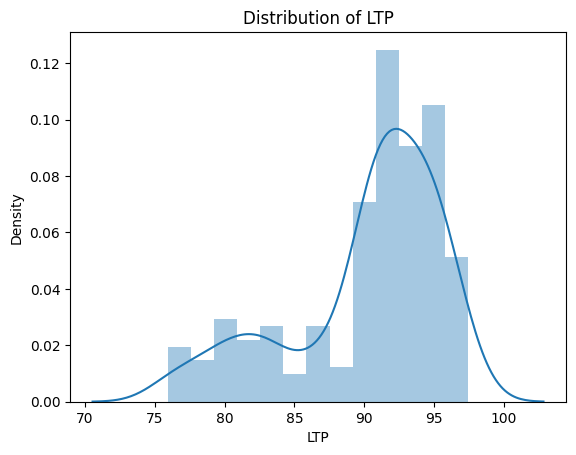

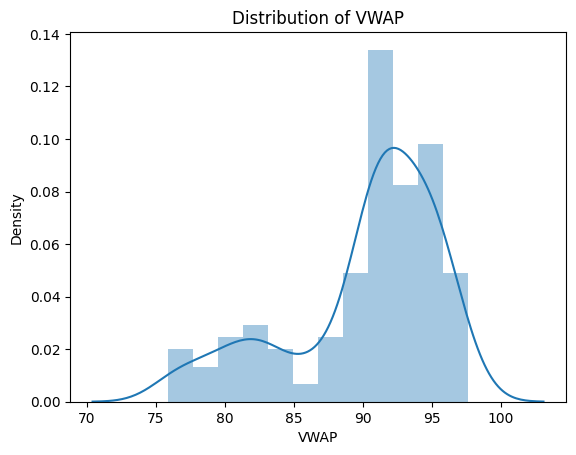

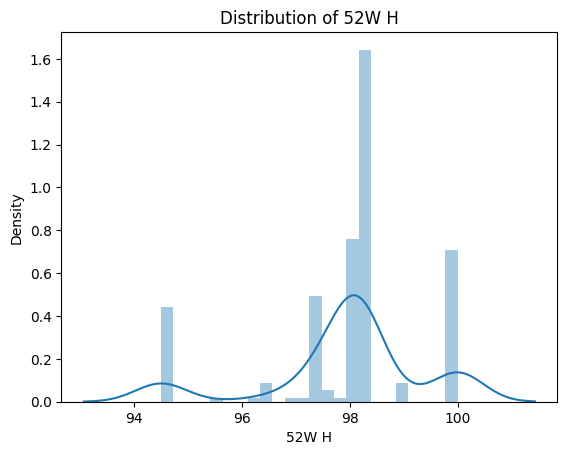

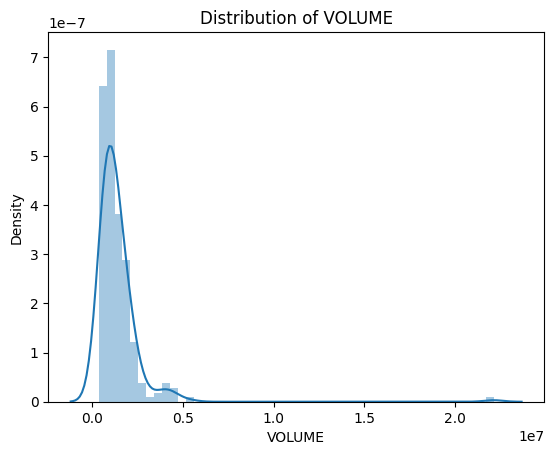

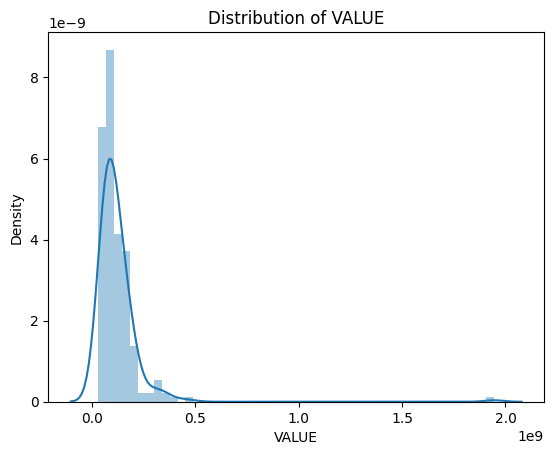

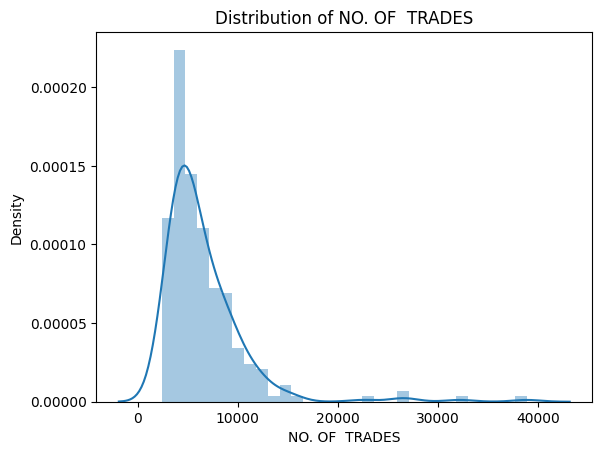

In [16]:
for col in columns:
    plt.figure()
    sns.distplot(PGINVIT[col])
    plt.title(f'Distribution of {col}')
    plt.show()

## TESt -->3 Multicollinerity test

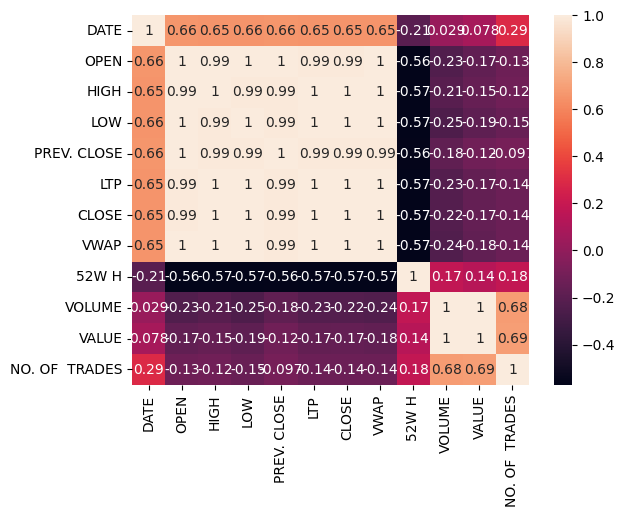

In [17]:
sns.heatmap(PGINVIT.corr(),annot=True)
plt.show()

## Test 4 --->AutoRegression(time based columns are not accepted)

In [18]:
PGINVIT.drop(columns=['DATE'],inplace=True)


In [19]:
PGINVIT.drop(columns=['52W H'],inplace=True)

In [20]:
PGINVIT

,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,VOLUME,VALUE,NO. OF TRADES
0,90.69,90.98,90.11,90.01,90.89,90.81,90.63,1455925,1.319544e+08,5975
1,90.25,91.30,89.90,90.20,90.00,90.01,90.22,2176809,1.964005e+08,8277
2,90.36,91.00,90.06,90.35,90.35,90.20,90.50,1443112,1.306063e+08,6450
3,90.11,90.58,89.95,90.11,90.41,90.35,90.11,1309905,1.180401e+08,6041
4,90.90,90.97,90.01,90.51,90.10,90.11,90.33,1843867,1.665525e+08,9449
...,...,...,...,...,...,...,...,...,...,...
242,75.99,76.25,75.70,75.99,76.00,75.99,76.04,4289545,3.261715e+08,9617
243,76.00,76.06,75.80,75.98,76.00,75.99,76.00,2727019,2.072488e+08,6853
244,75.76,76.10,75.60,75.99,75.94,75.98,75.92,3723960,2.827283e+08,7079
245,76.10,76.30,75.85,76.37,76.02,75.99,76.03,4124457,3.135633e+08,8972


# Train test split

In [21]:
X=PGINVIT.drop('CLOSE',axis=1) # features
Y=PGINVIT['CLOSE']  # target

In [22]:
X

,OPEN,HIGH,LOW,PREV. CLOSE,LTP,VWAP,VOLUME,VALUE,NO. OF TRADES
0,90.69,90.98,90.11,90.01,90.89,90.63,1455925,1.319544e+08,5975
1,90.25,91.30,89.90,90.20,90.00,90.22,2176809,1.964005e+08,8277
2,90.36,91.00,90.06,90.35,90.35,90.50,1443112,1.306063e+08,6450
3,90.11,90.58,89.95,90.11,90.41,90.11,1309905,1.180401e+08,6041
4,90.90,90.97,90.01,90.51,90.10,90.33,1843867,1.665525e+08,9449
...,...,...,...,...,...,...,...,...,...
242,75.99,76.25,75.70,75.99,76.00,76.04,4289545,3.261715e+08,9617
243,76.00,76.06,75.80,75.98,76.00,76.00,2727019,2.072488e+08,6853
244,75.76,76.10,75.60,75.99,75.94,75.92,3723960,2.827283e+08,7079
245,76.10,76.30,75.85,76.37,76.02,76.03,4124457,3.135633e+08,8972


In [23]:
Y

0      90.81
1      90.01
2      90.20
3      90.35
4      90.11
       ...  
242    75.99
243    75.99
244    75.98
245    75.99
246    76.37
Name: CLOSE, Length: 247, dtype: float64

In [24]:
# split the data
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.40,shuffle=True,random_state=42)

In [25]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(148, 9)
(99, 9)
(148,)
(99,)


In [26]:
X_train

,OPEN,HIGH,LOW,PREV. CLOSE,LTP,VWAP,VOLUME,VALUE,NO. OF TRADES
95,97.97,97.97,97.25,97.55,97.45,97.49,970339,9.459631e+07,4343
141,91.70,91.90,91.14,91.37,91.35,91.43,820392,7.500923e+07,5042
196,84.90,87.40,84.60,84.38,87.25,86.16,1799197,1.550137e+08,7033
76,95.00,95.00,94.55,94.64,94.70,94.74,911914,8.639181e+07,4707
41,92.25,92.99,91.66,92.50,91.70,92.16,1464078,1.349353e+08,8081
...,...,...,...,...,...,...,...,...,...
106,95.58,96.41,95.22,95.48,96.00,96.02,558845,5.365762e+07,3779
14,91.81,93.15,91.55,91.49,92.75,92.65,4436258,4.110102e+08,12560
92,97.39,98.19,97.00,97.09,97.30,97.62,1773508,1.731245e+08,9165
179,91.35,91.35,90.25,90.89,90.48,90.73,836902,7.592865e+07,4097


In [27]:
X_test

,OPEN,HIGH,LOW,PREV. CLOSE,LTP,VWAP,VOLUME,VALUE,NO. OF TRADES
33,91.99,93.40,88.95,91.67,92.30,91.98,1693641,1.557849e+08,6106
6,91.00,91.49,90.65,90.86,91.39,90.96,1400501,1.273827e+08,6399
181,91.75,91.99,90.00,90.66,90.50,90.84,2207294,2.005038e+08,6225
86,94.86,95.30,94.86,94.86,95.00,95.05,1416642,1.346468e+08,9846
155,93.69,93.69,92.01,93.19,93.42,93.19,612091,5.704058e+07,3522
...,...,...,...,...,...,...,...,...,...
22,90.19,90.19,89.70,89.95,89.84,89.93,1168380,1.050752e+08,8130
93,97.20,97.60,96.64,96.54,97.30,97.15,1725497,1.676302e+08,5528
192,86.16,87.04,86.16,86.99,86.85,86.86,1217910,1.057829e+08,4753
230,78.68,79.30,78.31,78.04,79.25,78.95,1821973,1.438532e+08,5932


In [28]:
Y_train

95     97.43
141    91.20
196    87.28
76     94.71
41     91.86
       ...  
106    95.94
14     92.68
92     97.27
179    90.42
102    95.99
Name: CLOSE, Length: 148, dtype: float64

In [29]:
Y_test

33     92.35
6      91.05
181    90.61
86     95.00
155    93.37
       ...  
22     89.83
93     97.09
192    86.88
230    79.15
51     91.32
Name: CLOSE, Length: 99, dtype: float64

# Model Building

In [30]:
Linear_model = LinearRegression()


# Model Training

In [31]:
Linear_model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
Linear_model.intercept_

np.float64(-0.6936440459723912)

In [33]:
Linear_model.coef_

array([-4.25770342e-02, -3.18070042e-02, -4.93737903e-02, -1.01820699e-02,
        7.73976737e-01,  3.66957222e-01,  3.98942443e-07, -4.23051294e-09,
       -2.11151654e-06])

In [34]:
y_pred =Linear_model.predict(X_test)
y_pred

array([92.28823168, 91.23942256, 90.50573316, 94.96863967, 93.34265749,
       89.8251995 , 86.76350636, 95.94686838, 91.03951259, 76.8925597 ,
       78.12721913, 83.44539135, 76.36419257, 90.48899755, 93.8719463 ,
       80.6137827 , 82.0348975 , 91.71829115, 90.89898919, 90.85790679,
       94.5552106 , 89.78196105, 94.65613272, 94.01066898, 82.43009216,
       93.04791183, 82.06091828, 91.34622552, 92.95872556, 97.3209432 ,
       77.20489735, 76.17107317, 95.48968323, 91.46744873, 76.06361114,
       89.74022949, 93.90748354, 82.93829824, 89.40858942, 92.87266852,
       82.64817343, 95.57384796, 89.1824077 , 91.34750579, 90.27511194,
       94.93743061, 94.09884384, 91.63078272, 91.74825769, 76.15417445,
       94.28643306, 83.09523978, 94.47652952, 86.93126322, 78.21911289,
       94.40595529, 90.38157131, 93.50422222, 97.20370183, 94.19812098,
       94.86999802, 95.2639716 , 95.44998466, 84.54434068, 96.04759245,
       93.83520429, 81.71537782, 96.39750467, 95.05934387, 86.84

In [42]:
y_train_pred =Linear_model.predict(X_train)

# Model Evaluation

In [35]:
error=Y_test-y_pred
error # or residuals

33     0.061768
6     -0.189423
181    0.104267
86     0.031360
155    0.027343
         ...   
22     0.038086
93    -0.144415
192    0.028239
230   -0.037722
51    -0.173121
Name: CLOSE, Length: 99, dtype: float64

In [36]:
error.shape

(99,)

# Test 5 Homoscadasticity

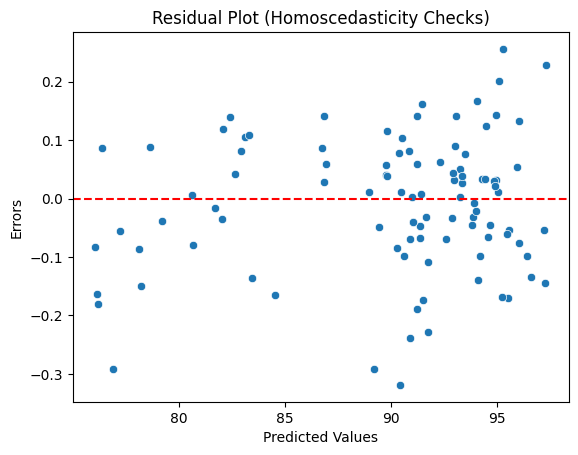

In [37]:
plt.figure()
sns.scatterplot(x=y_pred,y=error)
plt.axhline(y=0,color='r',linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Errors")
plt.title("Residual Plot (Homoscedasticity Checks)")
plt.show()

# Zero residual test

In [38]:
mean_residuals = np.mean(error)
mean_residuals

np.float64(-0.010443184255903458)

# Evaluation

# Test evaluation

In [39]:
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)

n=X_test.shape[0]
p=X_test.shape[1]
adj_r2 = 1-(1-r2)*(n-1)/(n-p-1)

print("mae:",mae)
print("mse:",mse)
print("rmse:",rmse)
print("r2:",r2)
print("adj r2 score:",adj_r2)

mae: 0.0919592559722241
mse: 0.013259430649231746
rmse: 0.11514960116835726
r2: 0.9996116517728284
adj r2 score: 0.9995723806037886


# Train evaluation

In [44]:
mae = mean_absolute_error(Y_train, y_train_pred)
mse = mean_squared_error(Y_train, y_train_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_train, y_train_pred)

n=X_train.shape[0]
p=X_train.shape[1]
adj_r2 = 1-(1-r2)*(n-1)/(n-p-1)

print("mae:",mae)
print("mse:",mse)
print("rmse:",rmse)
print("r2:",r2)
print("adj r2 score:",adj_r2)

mae: 0.08153280899297308
mse: 0.016749029571088488
rmse: 0.12941804190717957
r2: 0.9993587705235469
adj r2 score: 0.9993169512098652


In [40]:
print("Train R2:", Linear_model.score(X_train, Y_train))
print("Test R2:", Linear_model.score(X_test, Y_test))   # checking Overfitting

Train R2: 0.9993587705235469
Test R2: 0.9996116517728284


# Cross validation

In [41]:
scores = cross_val_score(Linear_model, X_train, Y_train, cv=5, scoring='r2')
print("Cross Val R2:", scores)
print("Mean CV R2:", scores.mean())

Cross Val R2: [0.99653728 0.99925341 0.99958267 0.99945311 0.99905192]
Mean CV R2: 0.9987756789523352


# Save Model

In [47]:
joblib.dump(Linear_model,"Linear_model.pkl")
print("Model trained and saved!")

Model trained and saved!


# Prediction

In [48]:
model = joblib.load("Linear_model.pkl")
y_pred = model.predict(X_test)

In [49]:
print("Predictions:",y_pred[:5])

Predictions: [92.28823168 91.23942256 90.50573316 94.96863967 93.34265749]
